# Utility vs Generalizaiton and Expensiveness of Annonymization Methods
This notebook investigates how the accuracy changes as generalization is applied.
**Conclussion**
Spoiler alert, the acuracy falls as generalization increases. Also, some annonymization requirements are much harsher than others. It strongly depends on the dataset

In [1]:
import masking_effects_on_xai_techniques.utils as utils
import masking_effects_on_xai_techniques.plot_creator_2 as plot_creator
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pl = plot_creator.PlotCreator(
    [
        "forest",
        "MLP",
        "knn"
    ],
    ["usa_house","usa_house_old", "cervic_cancer", "adult", "old_adult", "adult_imbalanced"],
    "../data/",
)

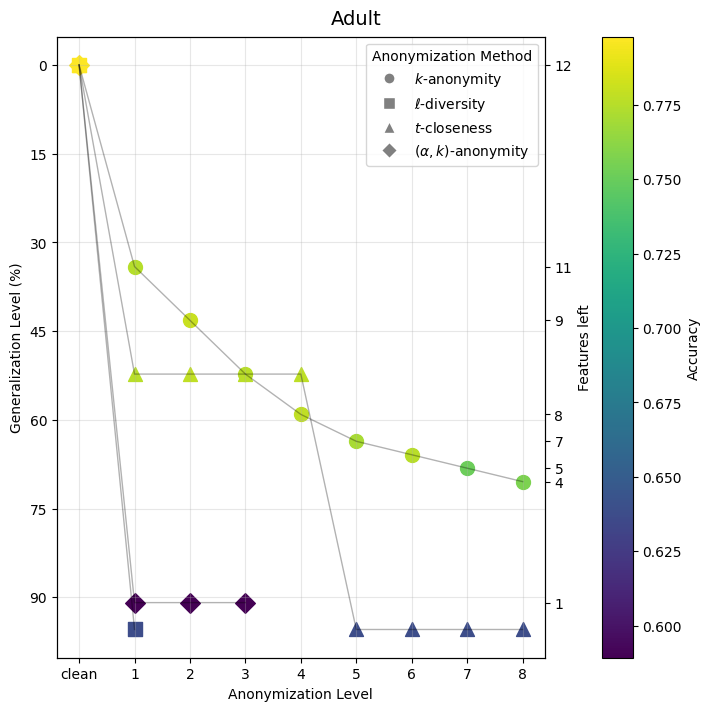

In [4]:
pl.plot_utility("adult", average_models=True)

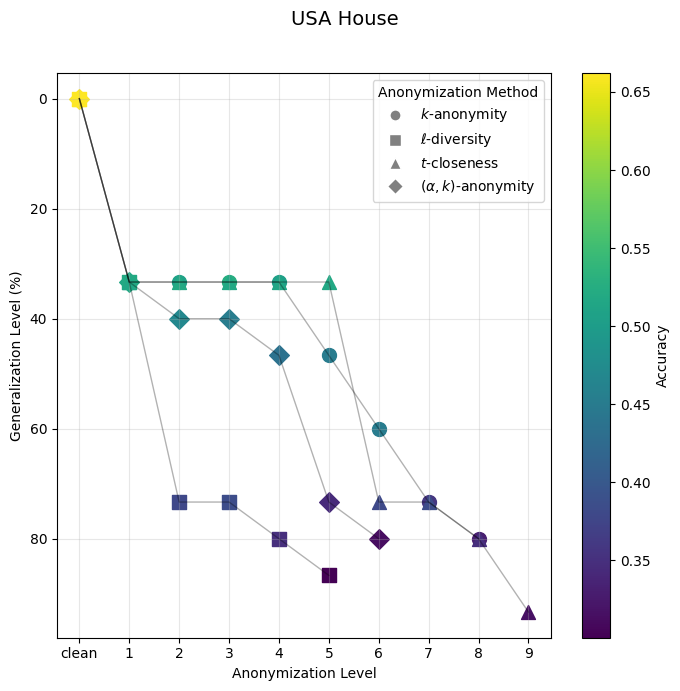

In [11]:
pl.plot_utility("usa_house", average_models=True)

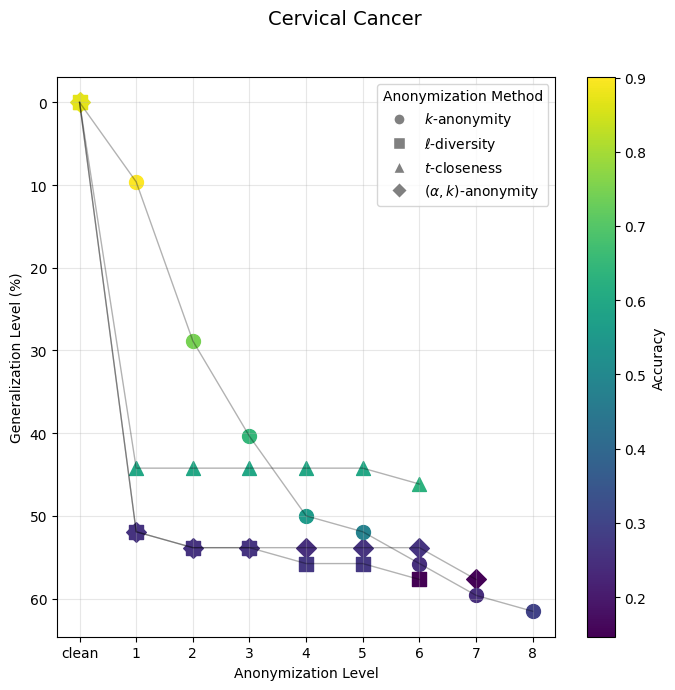

In [12]:
pl.plot_utility("cervic_cancer", average_models=True)

Note here that the accuracies are quite high. Initially it is quite good estimating income but as the dataset is genealized more the accuracy falls considerable. Also note that it never drops below 50. It is very dangerous to draw conclussions about the models utility from these plots, since we do not know the distribution of the target variable. Worst case scenario, the 20% that could be suppressed could al be focused on on target class, changing the distribution from 50 vs 50 to 70 vs 30. If that indeed happens, the model performs very poorly.  

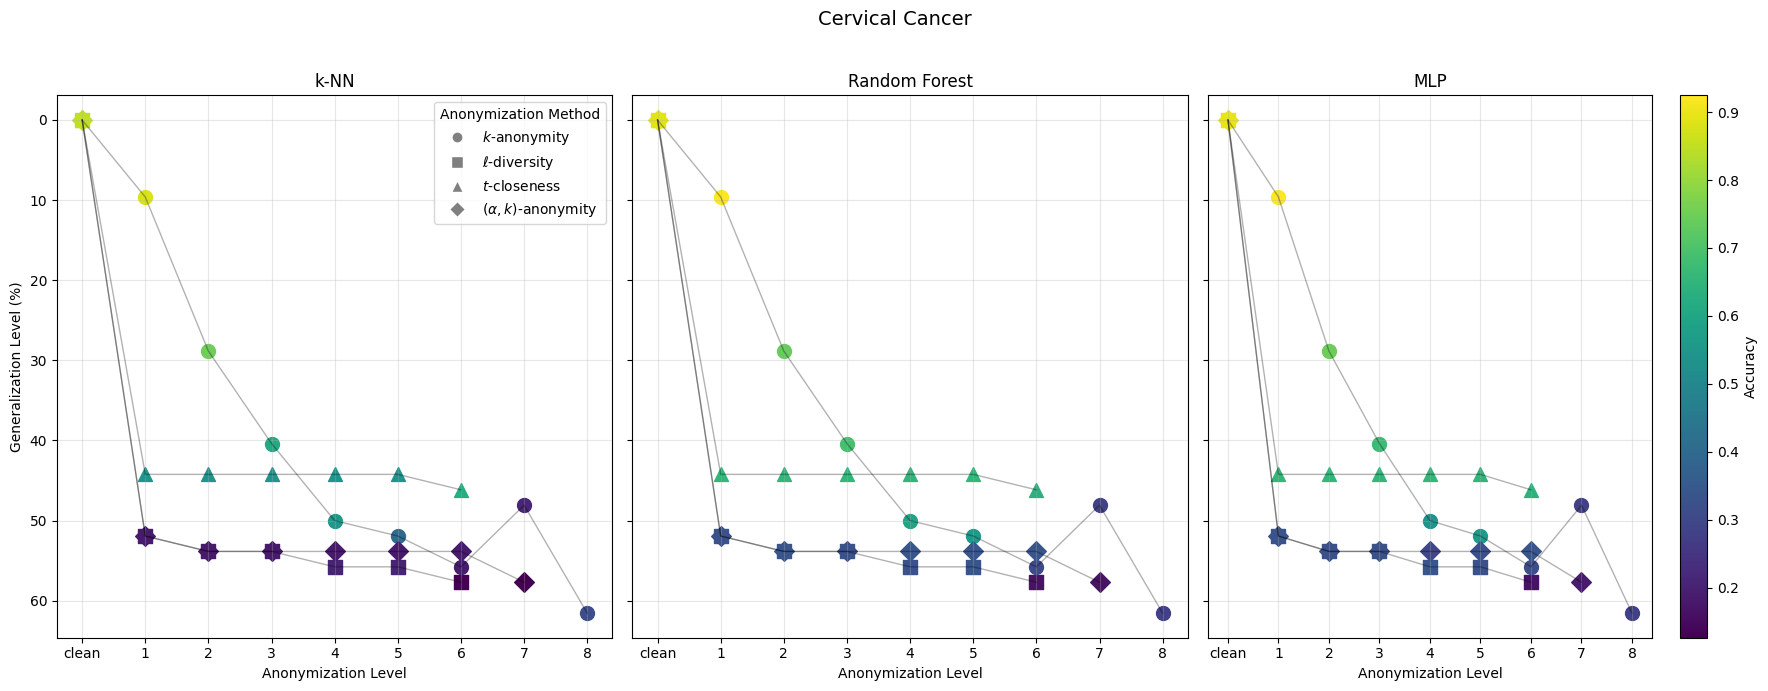

In [4]:
pl.plot_utility("cervic_cancer")

Same story here. Note there is a mistake in the generalizaiton level for k_anonymity at level 7. There is some kind of floating error where a categorical feature is mistaken for a floating number messing up the calculation. The real generalization is $30/52=57.6\%$

We also see that l_diversity and alpha_k_anonymity are very expensive to get. This is rather odd because there are like 8 target features which is the highest number across the three datasets. The reason is because a $k=10$ has been chosen. If you compare with the generalization level of k_anonymity 3 and 4 (8 and 16) the generalization level is up there. The last bit is added to make the equivalence classes. The fact that this dataset are bad at satisfying k anonymity has a huge impact on the difficulty of making satisfying the extra requirements. 

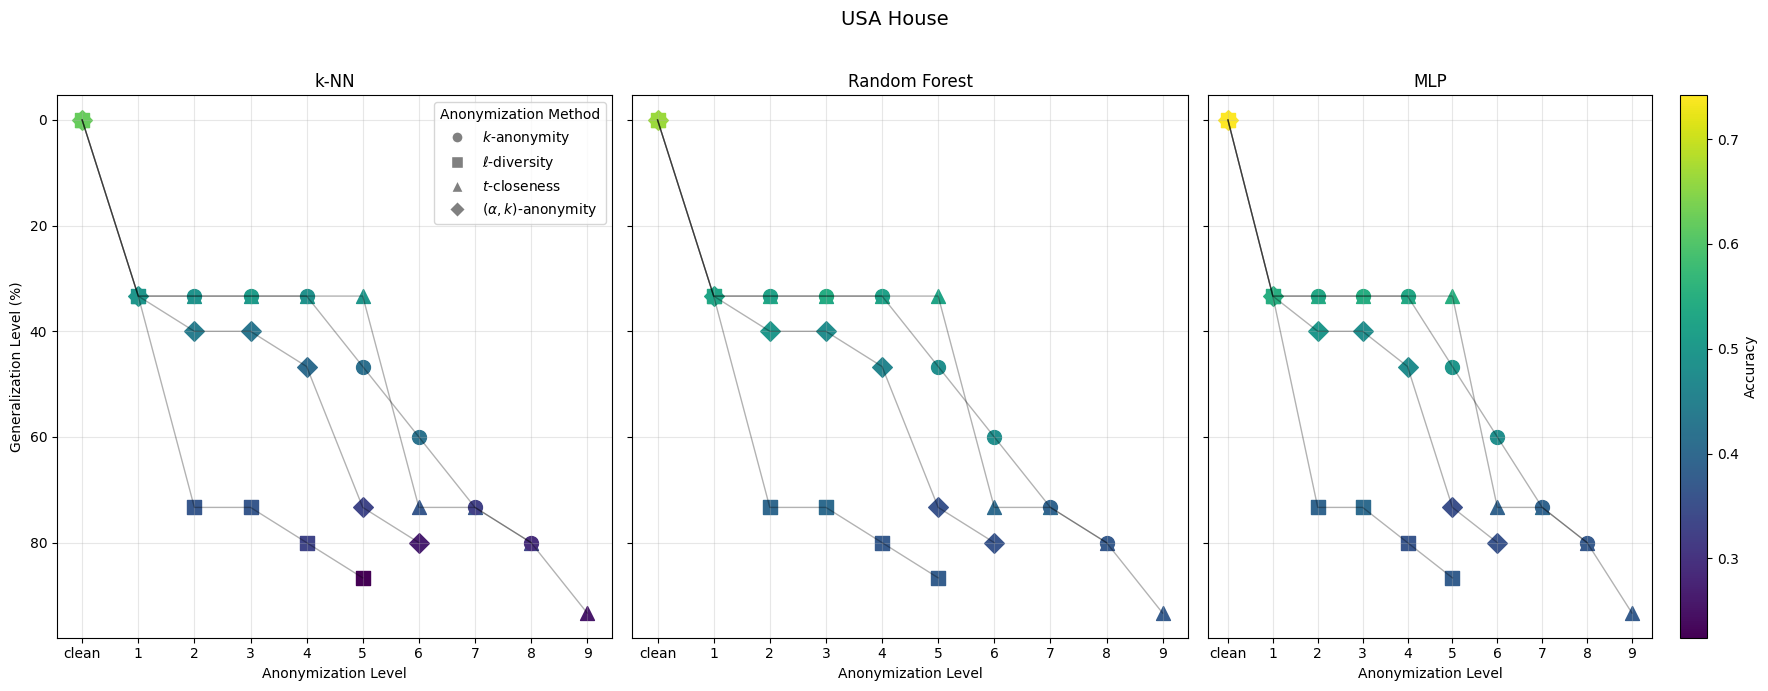

In [13]:
pl.plot_utility("usa_house")

Here k_anonymity is easier satisfied resulting in the initial high generalization level. Here we have that l_diversity is more difficult to obtain than alpha_k_anonymity. There are 5 target classes.  
Note for $l=3$ the data is generalized a lot. The target class is is discretized into bins. Once $l>2$ elements from the outer bins must be part of an equivalence class with elements from a non-adjacent bin. This requires a lot of loss in granularity

##### 